<a href="https://colab.research.google.com/github/Novita-data/hr-analytics-analytics-vidhya/blob/main/Assessment3_Novita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
filepath='/content/train_LZdllcl.csv'
df=pd.read_csv(filepath)
df.head(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [ ]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [ ]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


<Axes: xlabel='previous_year_rating', ylabel='Count'>

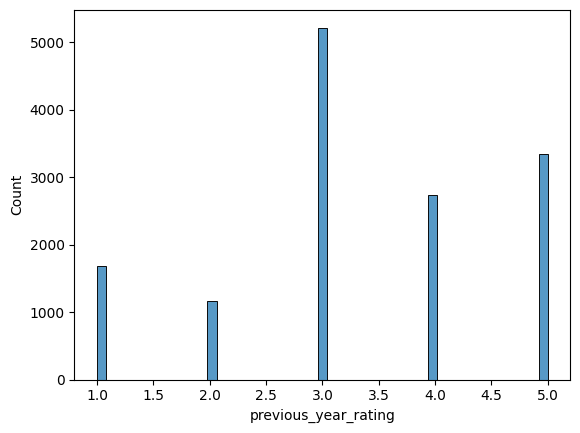

In [ ]:
#distribution checking
sns.histplot(data=df, x='previous_year_rating')

In [ ]:
df['previous_year_rating']= df['previous_year_rating'].fillna(df['previous_year_rating'].mean())

In [ ]:
df['education']=df['education'].fillna(df['education'].mode()[0])

In [ ]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [ ]:
# Select numerical columns automatically
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Display the selected columns
print(num_cols)

['employee_id', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score', 'is_promoted']


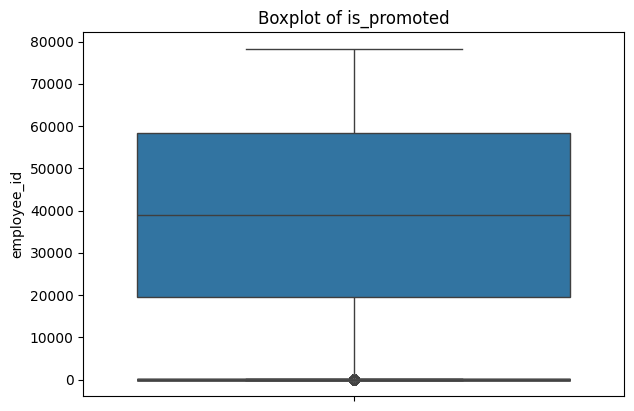

In [ ]:
# List numerical columns to plot

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, 2)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
#check target distribution
df['is_promoted'].value_counts()

,count
is_promoted,
0.0,13981
1.0,1312


In [ ]:
df['is_promoted'].value_counts(normalize=True) * 100

,proportion
is_promoted,
0.0,91.420912
1.0,8.579088


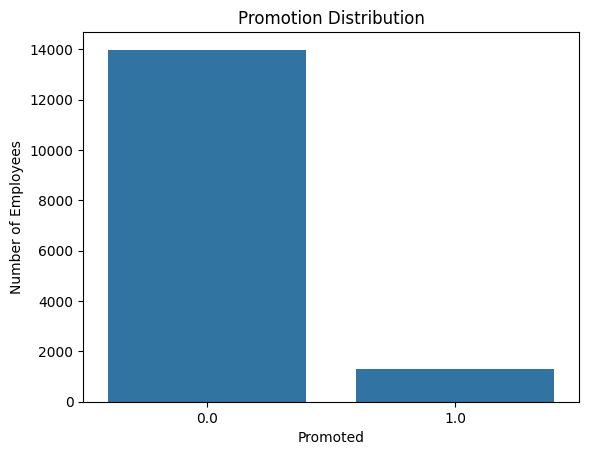

In [ ]:
sns.countplot(x='is_promoted', data=df)

plt.title("Promotion Distribution")
plt.xlabel("Promoted")
plt.ylabel("Number of Employees")
plt.show()

In [ ]:
#df = df.drop('employee_id', axis=1)

In [ ]:
#separating X and y
X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns

categorical_cols

Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object')

In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

numerical_cols

Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')

In [ ]:
#train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape
X_test.shape

(10962, 13)

In [ ]:
df['gender'].value_counts()

,count
gender,
m,38496
f,16312


In [ ]:
df['region'].value_counts()

,count
region,
region_2,12343
region_22,6428
region_7,4843
region_15,2808
region_13,2648
region_26,2260
region_31,1935
region_4,1703
region_27,1659


In [ ]:
df['recruitment_channel'].value_counts()

,count
recruitment_channel,
other,30446
sourcing,23220
referred,1142


In [ ]:
df['department'].value_counts()

,count
department,
Sales & Marketing,16840
Operations,11348
Technology,7138
Procurement,7138
Analytics,5352
Finance,2536
HR,2418
Legal,1039
R&D,999


In [ ]:
df['education'].value_counts()

,count
education,
Bachelor's,39078
Master's & above,14925
Below Secondary,805


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer


In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [ ]:
X_processed = preprocessor.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_processed)

print("Before PCA:", X_processed.shape)
print("After PCA:", X_pca.shape)

Before PCA: (54808, 59)
After PCA: (54808, 21)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE

In [ ]:
#Modelling

In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.37396392003900536


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.76      0.86     10028
           1       0.24      0.82      0.37       934

    accuracy                           0.77     10962
   macro avg       0.61      0.79      0.61     10962
weighted avg       0.92      0.77      0.81     10962



In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.76      0.86     10028
           1       0.24      0.82      0.37       934

    accuracy                           0.77     10962
   macro avg       0.61      0.79      0.61     10962
weighted avg       0.92      0.77      0.81     10962



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7627 2401]
 [ 167  767]]


In [ ]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=10
    ))
])

In [ ]:
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object'))])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                                        random_state=42))])

In [ ]:
dt_pred = dt_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))

Accuracy: 0.7115489874110563
Precision: 0.21435897435897436
Recall: 0.8950749464668094
F1 Score: 0.34588332643773273


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Accuracy: 0.9354132457580734
Precision: 0.928030303030303
Recall: 0.2623126338329764
F1 Score: 0.4090150250417362


In [ ]:
#best model is random forest and uploading test file

In [ ]:
best_model = rf_model
test_pred=pd.read_csv('/content/test_2umaH9m.csv')
test_pred = best_model.predict(test_pred)

In [ ]:
print(test_pred[:10])
print(len(test_pred))

[0 0 0 0 0 0 0 0 0 0]
23490


In [ ]:
#uploading sample submission file
sample_submission = pd.read_csv("/content/sample_submission_M0L0uXE.csv")

sample_submission.head(10)

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0
5,46232,0
6,54542,0
7,67269,0
8,66174,0
9,76303,0


In [ ]:
print(sample_submission.columns)
print(sample_submission.shape)

Index(['employee_id', 'is_promoted'], dtype='object')
(23490, 2)


In [ ]:
sample_submission['is_promoted'] = test_pred

In [ ]:
sample_submission.head(10)

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0
5,46232,0
6,54542,0
7,67269,0
8,66174,0
9,76303,0


In [ ]:
sample_submission.to_csv("promotion_best_submission.csv", index=False)

In [ ]:
submission = pd.read_csv("promotion_best_submission.csv")

print(submission.head())
print(submission.shape)
print(submission.isnull().sum())

   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0
(23490, 2)
employee_id    0
is_promoted    0
dtype: int64


In [ ]:
print("Test rows:", len(test_pred))
print("Submission rows:", len(submission))

Test rows: 23490
Submission rows: 23490
